In [1]:
# PyTorch and torchvision
import torch
import torchvision

# Helper libraries
import numpy as np
import matplotlib.pyplot as plt

# GPU 확인
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [2]:
import random

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [3]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms

dataset_dir = "~/datasets/stanfordimagenetdogs/Images/"

transform = transforms.Compose([
    transforms.Resize((224, 224)),  # 크기 통일
    transforms.ToTensor(),  # Tensor 변환
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # 정규화 추가
])
full_dataset = ImageFolder(root=dataset_dir, transform=transform)

total_size = len(full_dataset)
train_size = int(0.583 * total_size)  # 약 12,000개
test_size = total_size - train_size   # 약 8,580개
generator = torch.Generator().manual_seed(42)

ds_train, ds_test = random_split(
    full_dataset,
    [train_size, test_size],
    generator=generator
)

train_loader = DataLoader(ds_train, batch_size=32, shuffle=True)
test_loader = DataLoader(ds_test, batch_size=32, shuffle=False)
ds_info = {
    "num_classes": len(full_dataset.classes),
    "class_names": full_dataset.classes
}

print("=3")

=3


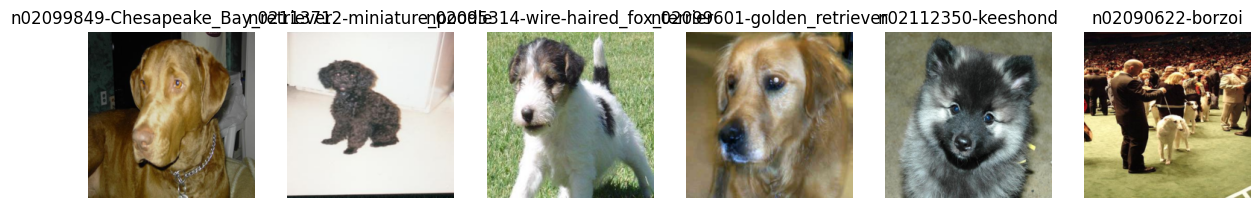

In [4]:
# DataLoader에서 일부 배치 가져오기
def show_examples(data_loader, class_names, num_images=6):
    data_iter = iter(data_loader)
    images, labels = next(data_iter)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))
    for i in range(num_images):
        image = images[i].permute(1, 2, 0).numpy()  # (C, H, W) → (H, W, C)
        image = (image * 0.5) + 0.5
        image = np.clip(image, 0, 1)

        axes[i].imshow(image)
        axes[i].axis('off')
        axes[i].set_title(class_names[labels[i].item()])

    plt.show()

# 훈련 데이터 샘플 시각화
show_examples(train_loader, ds_info["class_names"])

In [5]:
def normalize_and_resize_img():
    return transforms.Compose([
        transforms.Resize((224, 224)),  # 크기 통일
        transforms.ToTensor(),  # Tensor 변환
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # 정규화 추가
    ])

In [ ]:
def augment(): # 기본 augmentation만 
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ColorJitter(brightness=0.2)
    ])

print('=3')

=3


In [ ]:
# 데이터셋을 가공하는 메인함수
import copy
from torch.utils.data import Subset

def apply_normalize_on_dataset(dataset, is_test=False, batch_size=16, with_aug=False, seed=42):
    transform = normalize_and_resize_img()
    base_dataset = copy.copy(dataset.dataset)

    if not is_test and with_aug:
        base_dataset.transform = transforms.Compose([
            *augment().transforms,
            *transform.transforms
        ])
    else:
        base_dataset.transform = transform

    isolated_subset = Subset(base_dataset, dataset.indices)
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        isolated_subset,
        batch_size=batch_size,
        shuffle=not is_test, 
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )

print('=3')

=3


In [ ]:
'''
import random

def augment2():
    return transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),  # 좌우 반전
        transforms.RandomVerticalFlip(p=0.5),    # 상하 반전
        transforms.RandomChoice([
            transforms.RandomRotation((0, 0)),
            transforms.RandomRotation((90, 90)),
            transforms.RandomRotation((180, 180)),
            transforms.RandomRotation((270, 270)),
        ]),  # 0/90/180/270도 중 하나로 회전
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),  # 밝기, 대비, 색상 조정
        transforms.RandomResizedCrop(224, scale=(0.8, 1.0))  # 랜덤 크롭 후 리사이즈
    ])

print('=3')
폐기(augmentation이 너무 강한지 성능이 역순으로 나옴)
'''

=3


In [ ]:
import torch.nn as nn
import torchvision.models as models

num_classes = len(ds_info["class_names"])
torch.manual_seed(SEED) # 난수 고정 -> 새로 초기화되는 레이어의 가중치를 재현 가능하게
base_resnet50 = models.resnet50(
    weights=models.ResNet50_Weights.IMAGENET1K_V1
)
base_resnet50.fc = nn.Linear(base_resnet50.fc.in_features, num_classes) # 기존 출력 클래스 1000개 -> 120개(데이터셋), logit 
initial_model_state = copy.deepcopy(base_resnet50.state_dict())  # 모든 가중치 복사해 보관하고 mixup, cutmix도 여기서 시작 

resnet50 = copy.deepcopy(base_resnet50)
aug_resnet50 = copy.deepcopy(base_resnet50)
del base_resnet50

print("=3")


=3


In [10]:
ds_train_no_aug = apply_normalize_on_dataset(ds_train, with_aug=False, seed=SEED)
ds_train_aug = apply_normalize_on_dataset(ds_train, with_aug=True, seed=SEED)
ds_test = apply_normalize_on_dataset(ds_test, is_test=True, seed=SEED)

print("=3")

=3


In [ ]:
%%time
import torch.optim as optim

 # Augentation 적용 효과를 확인하기 위해 필요한 epoch 수
EPOCH = 10
criterion = nn.CrossEntropyLoss()

def train(model, train_loader, test_loader, epochs, seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # seed 고정 -> 동일조건 구성 

    model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.001)
    history = {'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1) # 가장 높은 logit 값의 견종 번호 -> 선택 
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        print(f"Epoch [{epoch+1}/{epochs}], Accuracy: {train_acc:.2f}%")

        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)
        print(f"Validation Accuracy: {val_acc:.2f}%")

    return history
# no aug 학습 
history_resnet50_no_aug = train(resnet50, ds_train_no_aug, ds_test, EPOCH)
torch.save(history_resnet50_no_aug, 'history_no_augmentation.pt')
resnet50.to('cpu')
if torch.cuda.is_available():
    torch.cuda.empty_cache()
# aug 학습 
history_resnet50_aug = train(aug_resnet50, ds_train_aug, ds_test, EPOCH)
torch.save(history_resnet50_aug, 'history_basic_augmentation.pt')
aug_resnet50.to('cpu')
if torch.cuda.is_available():
    torch.cuda.empty_cache()

/home/thkim0/venv/v1/lib/python3.10/site-packages/torch/nn/modules/conv.py:459: UserWarning: Applied workaround for CuDNN issue, install nvrtc.so (Triggered internally at ../aten/src/ATen/native/cudnn/Conv_v8.cpp:80.)
  return F.conv2d(input, weight, bias, self.stride,


Epoch [1/10], Accuracy: 15.49%
Validation Accuracy: 42.61%
Epoch [2/10], Accuracy: 48.27%
Validation Accuracy: 62.63%
Epoch [3/10], Accuracy: 61.55%
Validation Accuracy: 70.32%
Epoch [4/10], Accuracy: 69.79%
Validation Accuracy: 75.83%
Epoch [5/10], Accuracy: 73.93%
Validation Accuracy: 78.12%
Epoch [6/10], Accuracy: 77.37%
Validation Accuracy: 79.77%
Epoch [7/10], Accuracy: 79.13%
Validation Accuracy: 81.17%
Epoch [8/10], Accuracy: 81.41%
Validation Accuracy: 82.00%
Epoch [9/10], Accuracy: 83.19%
Validation Accuracy: 82.87%
Epoch [10/10], Accuracy: 84.81%
Validation Accuracy: 83.16%
Epoch [1/10], Accuracy: 15.52%
Validation Accuracy: 42.50%
Epoch [2/10], Accuracy: 48.02%
Validation Accuracy: 62.54%
Epoch [3/10], Accuracy: 61.13%
Validation Accuracy: 70.51%
Epoch [4/10], Accuracy: 69.16%
Validation Accuracy: 75.61%
Epoch [5/10], Accuracy: 73.21%
Validation Accuracy: 77.97%
Epoch [6/10], Accuracy: 75.93%
Validation Accuracy: 79.76%
Epoch [7/10], Accuracy: 77.81%
Validation Accuracy: 81.

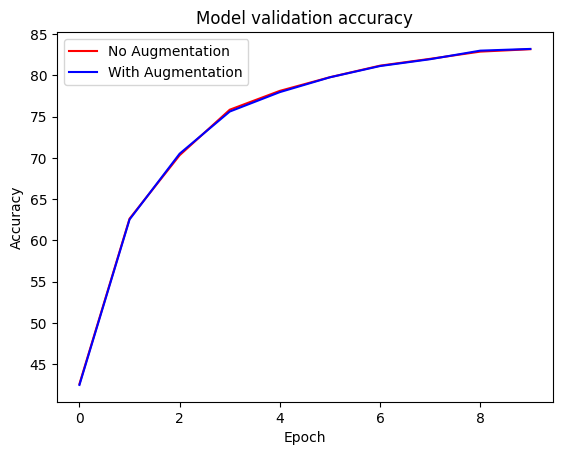

In [12]:
plt.plot(history_resnet50_no_aug['val_accuracy'], 'r', label='No Augmentation')
plt.plot(history_resnet50_aug['val_accuracy'], 'b', label='With Augmentation')
plt.title('Model validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.show()

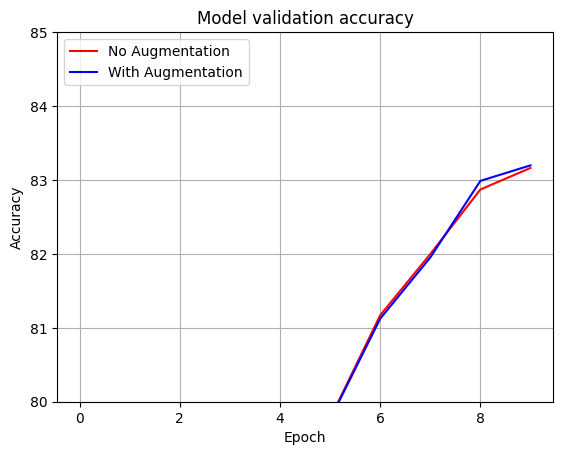

In [18]:
plt.plot(history_resnet50_no_aug['val_accuracy'], 'r', label='No Augmentation')
plt.plot(history_resnet50_aug['val_accuracy'], 'b', label='With Augmentation')
plt.title('Model validation accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.ylim(80, 85)
plt.show()

모델을 구성할 때 뭔가 이상한 부분을 눈치채셨나요? 모델에 softmax를 구조적으로 명시하지 않아도 되는 이유는 무엇일까요?

-> nn.CrossEntropyLoss가 내부적으로 LogSoftmax + NLLLoss 연산 수행함 



PyTorch에서 모델의 출력은 어떤 형태인가요? 우리가 확인하고 싶은 수치는 다른 형태입니다. 이를 위해 모델의 출력을 어떻게 확률 형태로 변환할 수 있을까요?

-> logit(정규화되지 않은 점수, ln(p/(1-p)))


logit으로 나오는 모델의 output을 확률 형태로 변환하기 위해 softmax를 적용해야 합니다. 그러나 우리 모델의 출력단에는 softmax를 명시하지 않았습니다. 그렇다면 어디서 softmax변환이 이루어질까요?
-> nn.CrossEntropyLoss

## ResNet-50 네 가지 Augmentation 비교

No Augmentation, 기본 Augmentation, 기본 Augmentation + MixUp, 기본 Augmentation + CutMix의 견종 분류 정확도를 비교합니다.

In [19]:
def mixup_batch(images, labels, alpha=1.0):
    lam = np.random.beta(alpha, alpha) # 이미지를 섞는 비율 
    indices = torch.randperm(images.size(0), device=images.device)
    mixed_images = lam * images + (1.0 - lam) * images[indices]
    return mixed_images, labels, labels[indices], float(lam)


def cutmix_batch(images, labels, alpha=1.0):
    lam = np.random.beta(alpha, alpha) 
    indices = torch.randperm(images.size(0), device=images.device)

    height, width = images.shape[-2:] # N, C, H, W 중 HW
    cut_ratio = np.sqrt(1.0 - lam)    # 면적비율 -> sqrt 
    cut_width = int(width * cut_ratio)
    cut_height = int(height * cut_ratio)

    center_x = torch.randint(width, (1,), device=images.device).item()
    center_y = torch.randint(height, (1,), device=images.device).item()
    x1 = max(center_x - cut_width // 2, 0) # 사각형이 원본 이미지 밖으로 나가지 않도록 최대/최소 지정 
    x2 = min(center_x + cut_width // 2, width)
    y1 = max(center_y - cut_height // 2, 0)
    y2 = min(center_y + cut_height // 2, height)

    mixed_images = images.clone() # 원본 직접 수정하면 안되니까 
    mixed_images[:, :, y1:y2, x1:x2] = images[indices, :, y1:y2, x1:x2]

    replaced_ratio = ((x2 - x1) * (y2 - y1)) / (width * height)
    adjusted_lam = 1.0 - replaced_ratio
    return mixed_images, labels, labels[indices], adjusted_lam


def mixed_loss(criterion, outputs, labels_a, labels_b, lam): # 원래 라벨 loss + 섞인 라벨 loss 
    return lam * criterion(outputs, labels_a) + (1.0 - lam) * criterion(outputs, labels_b)

In [20]:
import copy
import torch.optim as optim

MIX_EPOCHS = EPOCH
MIX_ALPHA = 1.0
MIX_BATCH_SIZE = ds_train_aug.batch_size
MIX_SEED = 42


def make_train_loader(train_dataset, seed):
    generator = torch.Generator().manual_seed(seed)
    return DataLoader(
        train_dataset,
        batch_size=MIX_BATCH_SIZE,
        shuffle=True,
        num_workers=2,
        pin_memory=torch.cuda.is_available(),
        generator=generator,
    )


def evaluate_model(model, data_loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            predicted = outputs.argmax(dim=1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return 100.0 * correct / total


def train_with_batch_mix(model, train_loader, test_loader, mode, epochs, alpha=1.0):
    random.seed(MIX_SEED)
    np.random.seed(MIX_SEED)
    torch.manual_seed(MIX_SEED)
    torch.cuda.manual_seed_all(MIX_SEED)

    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=0.001)
    history = {'train_loss': [], 'train_accuracy': [], 'val_accuracy': []}

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        weighted_correct = 0.0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            if mode == 'mixup':
                mixed_images, labels_a, labels_b, lam = mixup_batch(images, labels, alpha)
            elif mode == 'cutmix':
                mixed_images, labels_a, labels_b, lam = cutmix_batch(images, labels, alpha)
            else:
                raise ValueError("mode must be 'mixup' or 'cutmix'")

            optimizer.zero_grad()
            outputs = model(mixed_images)
            loss = mixed_loss(criterion, outputs, labels_a, labels_b, lam)
            loss.backward()
            optimizer.step()

            predicted = outputs.argmax(dim=1)
            batch_size = labels.size(0)
            running_loss += loss.item() * batch_size
            weighted_correct += lam * predicted.eq(labels_a).sum().item()
            weighted_correct += (1.0 - lam) * predicted.eq(labels_b).sum().item()
            total += batch_size

        train_loss = running_loss / total
        train_acc = 100.0 * weighted_correct / total
        val_acc = evaluate_model(model, test_loader)

        history['train_loss'].append(train_loss)
        history['train_accuracy'].append(train_acc)
        history['val_accuracy'].append(val_acc)
        print(
            f"{mode.upper()} Epoch [{epoch + 1}/{epochs}] "
            f"Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.2f}%, "
            f"Validation Accuracy: {val_acc:.2f}%"
        )

    return history


# 앞의 두 모델과도 완전히 동일한 초기 가중치에서 시작합니다.
mixup_resnet50 = models.resnet50(weights=None)
mixup_resnet50.fc = nn.Linear(mixup_resnet50.fc.in_features, num_classes)
mixup_resnet50.load_state_dict(initial_model_state)
cutmix_resnet50 = models.resnet50(weights=None)
cutmix_resnet50.fc = nn.Linear(cutmix_resnet50.fc.in_features, num_classes)
cutmix_resnet50.load_state_dict(initial_model_state)

# 기본 Augmentation이 적용되는 동일한 데이터셋을 두 실험에 사용합니다.
mixup_loader = make_train_loader(ds_train_aug.dataset, MIX_SEED)
cutmix_loader = make_train_loader(ds_train_aug.dataset, MIX_SEED)

history_mixup = train_with_batch_mix(
    mixup_resnet50, mixup_loader, ds_test, 'mixup', MIX_EPOCHS, MIX_ALPHA
)
torch.save(history_mixup, 'history_basic_mixup.pt')
mixup_resnet50.to('cpu')
if torch.cuda.is_available():
    torch.cuda.empty_cache()

history_cutmix = train_with_batch_mix(
    cutmix_resnet50, cutmix_loader, ds_test, 'cutmix', MIX_EPOCHS, MIX_ALPHA
)
torch.save(history_cutmix, 'history_basic_cutmix.pt')
cutmix_resnet50.to('cpu')
if torch.cuda.is_available():
    torch.cuda.empty_cache()

MIXUP Epoch [1/10] Loss: 4.6523, Train Accuracy: 5.56%, Validation Accuracy: 24.31%
MIXUP Epoch [2/10] Loss: 4.2624, Train Accuracy: 22.45%, Validation Accuracy: 51.72%
MIXUP Epoch [3/10] Loss: 3.8278, Train Accuracy: 33.52%, Validation Accuracy: 61.63%
MIXUP Epoch [4/10] Loss: 3.4679, Train Accuracy: 39.49%, Validation Accuracy: 68.45%
MIXUP Epoch [5/10] Loss: 3.2240, Train Accuracy: 43.34%, Validation Accuracy: 70.75%
MIXUP Epoch [6/10] Loss: 2.9678, Train Accuracy: 47.09%, Validation Accuracy: 73.71%
MIXUP Epoch [7/10] Loss: 2.8547, Train Accuracy: 48.40%, Validation Accuracy: 76.46%
MIXUP Epoch [8/10] Loss: 2.7176, Train Accuracy: 50.72%, Validation Accuracy: 77.98%
MIXUP Epoch [9/10] Loss: 2.6608, Train Accuracy: 51.49%, Validation Accuracy: 79.12%
MIXUP Epoch [10/10] Loss: 2.5952, Train Accuracy: 52.84%, Validation Accuracy: 79.95%
CUTMIX Epoch [1/10] Loss: 4.6901, Train Accuracy: 4.03%, Validation Accuracy: 20.17%
CUTMIX Epoch [2/10] Loss: 4.3793, Train Accuracy: 17.35%, Validat

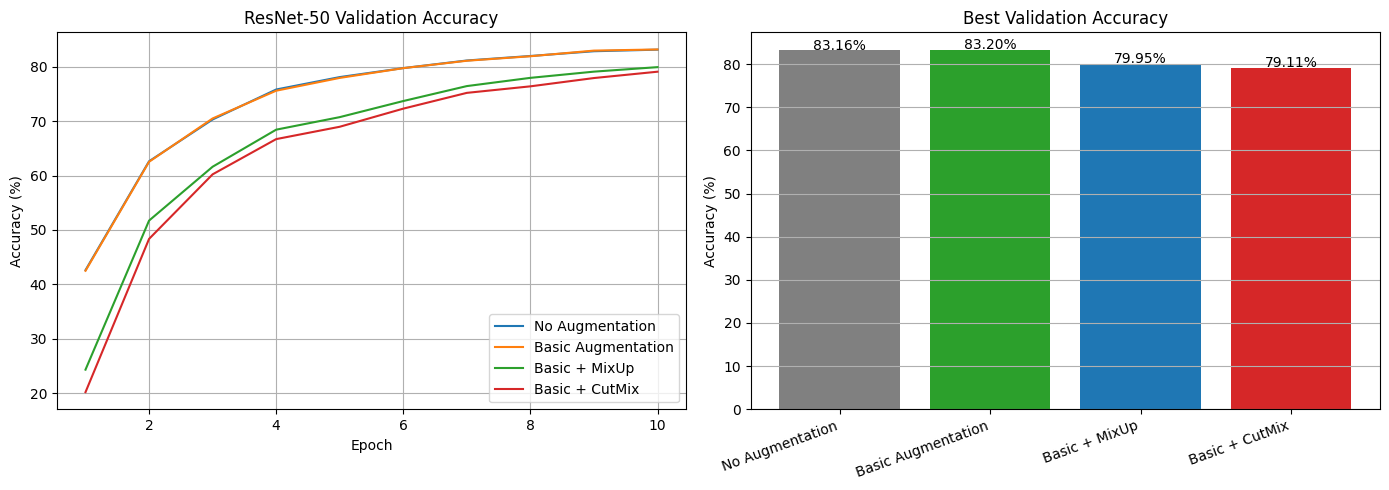

No Augmentation           | Best:  83.16% | Final:  83.16%
Basic Augmentation        | Best:  83.20% | Final:  83.20%
Basic + MixUp             | Best:  79.95% | Final:  79.95%
Basic + CutMix            | Best:  79.11% | Final:  79.11%


In [21]:
base_epochs = range(1, len(history_resnet50_no_aug['val_accuracy']) + 1)
mix_epochs = range(1, len(history_mixup['val_accuracy']) + 1)

comparison = {
    'No Augmentation': history_resnet50_no_aug['val_accuracy'],
    'Basic Augmentation': history_resnet50_aug['val_accuracy'],
    'Basic + MixUp': history_mixup['val_accuracy'],
    'Basic + CutMix': history_cutmix['val_accuracy'],
}

# 결과에 맞게 직접 수정하세요. 예: (75, 90), 자동 범위는 None
ACCURACY_YLIM = None

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(base_epochs, comparison['No Augmentation'], label='No Augmentation')
plt.plot(base_epochs, comparison['Basic Augmentation'], label='Basic Augmentation')
plt.plot(mix_epochs, comparison['Basic + MixUp'], label='Basic + MixUp')
plt.plot(mix_epochs, comparison['Basic + CutMix'], label='Basic + CutMix')
plt.title('ResNet-50 Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
if ACCURACY_YLIM is not None:
    plt.ylim(*ACCURACY_YLIM)
plt.grid(True)
plt.legend()

plt.subplot(1, 2, 2)
names = list(comparison.keys())
best_accuracies = [max(values) for values in comparison.values()]
bars = plt.bar(names, best_accuracies, color=['gray', 'tab:green', 'tab:blue', 'tab:red'])
plt.title('Best Validation Accuracy')
plt.ylabel('Accuracy (%)')
plt.xticks(rotation=20, ha='right')
plt.grid(axis='y')
for bar, accuracy in zip(bars, best_accuracies):
    plt.text(bar.get_x() + bar.get_width() / 2, accuracy + 0.2, f'{accuracy:.2f}%', ha='center')

plt.tight_layout()
plt.show()

for name, accuracies in comparison.items():
    print(f'{name:25s} | Best: {max(accuracies):6.2f}% | Final: {accuracies[-1]:6.2f}%')

--- 

### 결과

---


Augmentation의 개념이 데이터셋에 조작을 가해 좀 더 풍성하게 만들어서 데이터셋이 넓어진 것 같은 효과를 주기에 정확도가 좋아지기만 할 것으로 예상을 했었는데 실제 결과는 정반대로 Basic augmentation이 아주 아주 아주 아주 아주 아주 아주 근소하게 나아지는 성능을 보였고, mixup이나 cutmix를 적용한 모델들은 오히려 성능이 떨어지는 모습을 보였다. 


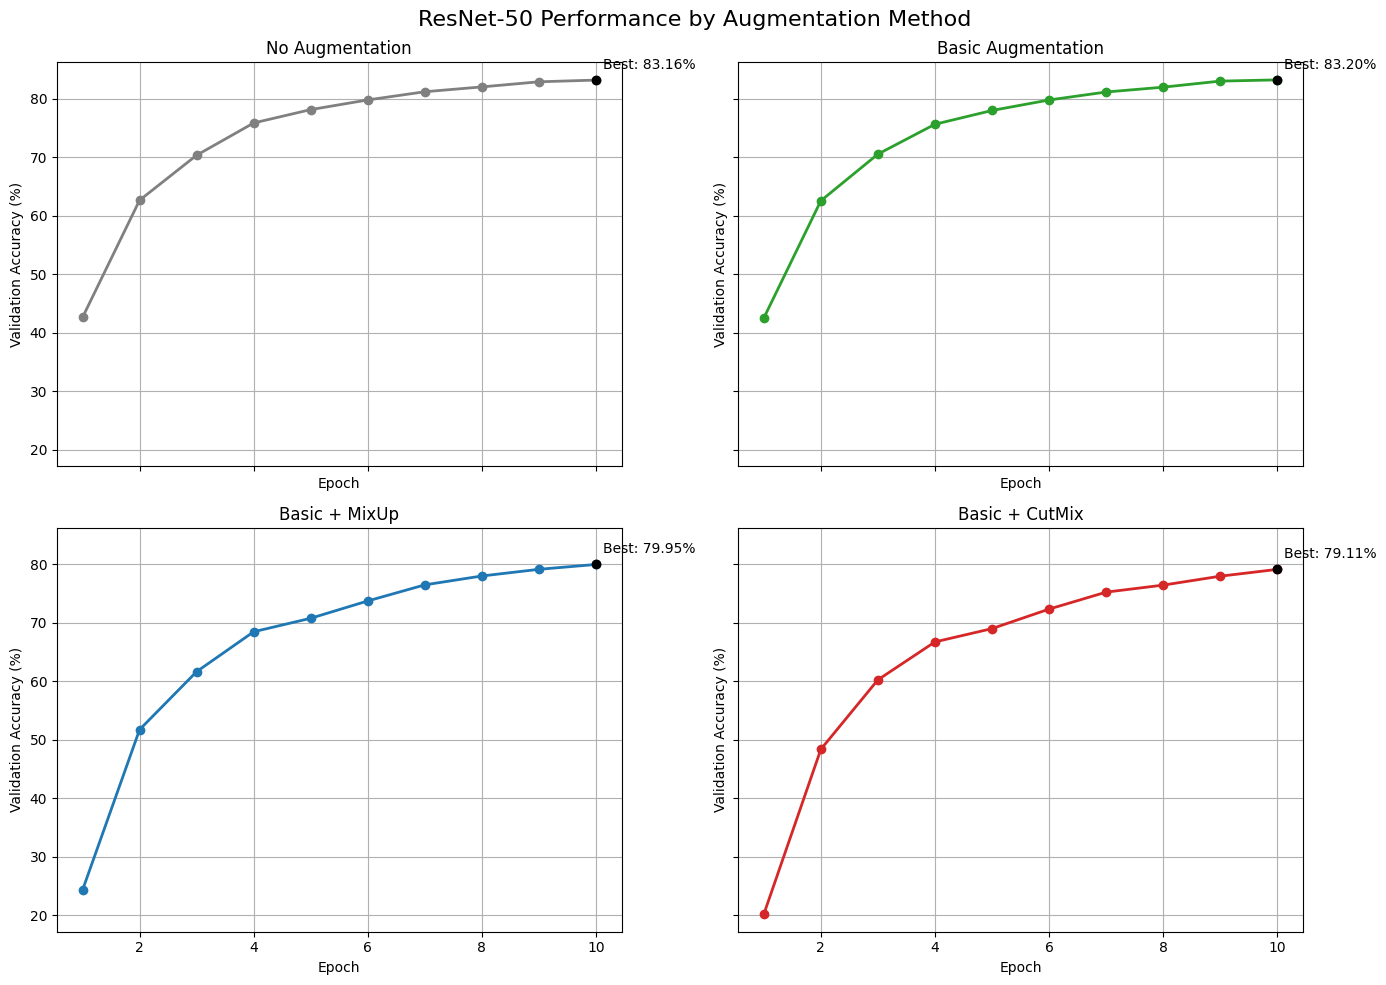

In [22]:
# 모델별 validation accuracy 변화
colors = ['gray', 'tab:green', 'tab:blue', 'tab:red']
all_accuracies = [accuracy for values in comparison.values() for accuracy in values]
if ACCURACY_YLIM is None:
    y_min = max(0, min(all_accuracies) - 3)
    y_max = min(100, max(all_accuracies) + 3)
else:
    y_min, y_max = ACCURACY_YLIM

fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex=True, sharey=True)

for ax, (name, accuracies), color in zip(axes.flat, comparison.items(), colors):
    epochs = range(1, len(accuracies) + 1)
    best_index = int(np.argmax(accuracies))
    best_epoch = best_index + 1
    best_accuracy = accuracies[best_index]

    ax.plot(epochs, accuracies, marker='o', color=color, linewidth=2)
    ax.scatter(best_epoch, best_accuracy, color='black', zorder=3)
    ax.annotate(
        f'Best: {best_accuracy:.2f}%',
        (best_epoch, best_accuracy),
        xytext=(5, 8),
        textcoords='offset points',
    )
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Validation Accuracy (%)')
    ax.set_ylim(y_min, y_max)
    ax.grid(True)

fig.suptitle('ResNet-50 Performance by Augmentation Method', fontsize=16)
plt.tight_layout()
plt.show()